In [ ]:
# pip install prophet

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json

In [ ]:
from prophet import Prophet
from prophet.diagnostics import cross_validation, performance_metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [ ]:
store1 = pd.read_csv('store1_timeseries.csv',
                      parse_dates=['Date'], index_col='Date')

In [ ]:
split_date = '2015-06-15'
s1_train = store1[store1.index < split_date].copy()
s1_test  = store1[store1.index >= split_date].copy()

print(f"Train: {s1_train.shape} | {s1_train.index.min()} to {s1_train.index.max()}")
print(f"Test : {s1_test.shape}  | {s1_test.index.min()} to {s1_test.index.max()}")

Train: (740, 4) | 2013-01-02 00:00:00 to 2015-06-13 00:00:00
Test : (41, 4)  | 2015-06-15 00:00:00 to 2015-07-31 00:00:00


In [ ]:
train_prophet = s1_train.reset_index()[['Date', 'Sales', 'Promo', 'IsHoliday']].rename(
    columns={'Date': 'ds', 'Sales': 'y'})

test_prophet = s1_test.reset_index()[['Date', 'Sales', 'Promo', 'IsHoliday']].rename(
    columns={'Date': 'ds', 'Sales': 'y'})

In [ ]:
print(f"Min sales in train: {train_prophet['y'].min()}")
print(f"Any zeros: {(train_prophet['y'] == 0).sum()}")
print(f"\nTrain shape : {train_prophet.shape}")
print(f"Test shape  : {test_prophet.shape}")
print(train_prophet.head())

Min sales in train: 2362
Any zeros: 0

Train shape : (740, 4)
Test shape  : (41, 4)
          ds     y  Promo  IsHoliday
0 2013-01-02  5530      0          0
1 2013-01-03  4327      0          0
2 2013-01-04  4486      0          0
3 2013-01-05  4997      0          0
4 2013-01-07  7176      1          0


In [ ]:
model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    seasonality_mode='multiplicative',
    changepoint_prior_scale=0.05,
    seasonality_prior_scale=10,
    interval_width=0.95
)

In [ ]:
model.add_country_holidays(country_name='DE')

In [ ]:
model.add_regressor('Promo')
model.add_regressor('IsHoliday')

In [ ]:
model.fit(train_prophet[['ds', 'y', 'Promo', 'IsHoliday']])
print("Prophet model fitted successfully")

Prophet model fitted successfully


In [ ]:
future = test_prophet[['ds', 'Promo', 'IsHoliday']].copy()
forecast = model.predict(future)

In [ ]:
print("Forecast columns available:")
print([c for c in forecast.columns if any(k in c for k in
      ['yhat', 'trend', 'seasonal', 'holiday'])])
print(f"\nForecast shape: {forecast.shape}")
print(forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].head(10))

Forecast columns available:
['trend', 'yhat_lower', 'yhat_upper', 'trend_lower', 'trend_upper', 'holidays', 'holidays_lower', 'holidays_upper', 'yhat']

Forecast shape: (41, 58)
          ds         yhat   yhat_lower   yhat_upper
0 2015-06-15  5526.455997  4235.434721  6801.412544
1 2015-06-16  5074.370215  3806.544507  6340.304792
2 2015-06-17  4965.866884  3744.231951  6236.830719
3 2015-06-18  4838.464514  3566.362265  6060.281950
4 2015-06-19  5135.328407  3889.323968  6355.583019
5 2015-06-20  4726.223962  3533.317025  6106.169336
6 2015-06-22  4202.145703  2958.729627  5398.211207
7 2015-06-23  3736.335744  2489.657965  4931.786459
8 2015-06-24  3615.777421  2490.599163  4903.381277
9 2015-06-25  3478.483158  2279.208914  4633.976628


In [ ]:
def mape(actual, predicted):
    actual, predicted = np.array(actual), np.array(predicted)
    mask = actual != 0
    return np.mean(np.abs((actual[mask] - predicted[mask]) / actual[mask])) * 100

actuals = test_prophet['y'].values
preds   = forecast['yhat'].values

preds = np.clip(preds, 0, None)

mae      = mean_absolute_error(actuals, preds)
rmse     = np.sqrt(mean_squared_error(actuals, preds))
mape_val = mape(actuals, preds)

print("=" * 40)
print("Prophet — Store 1 Performance (Daily)")
print("=" * 40)
print(f"  MAE  : {mae:,.2f}")
print(f"  RMSE : {rmse:,.2f}")
print(f"  MAPE : {mape_val:.2f}%")
print("=" * 40)

prophet_metrics = {'Model': 'Prophet', 'MAE': mae, 'RMSE': rmse, 'MAPE': mape_val}

Prophet — Store 1 Performance (Daily)
  MAE  : 344.91
  RMSE : 443.65
  MAPE : 7.96%


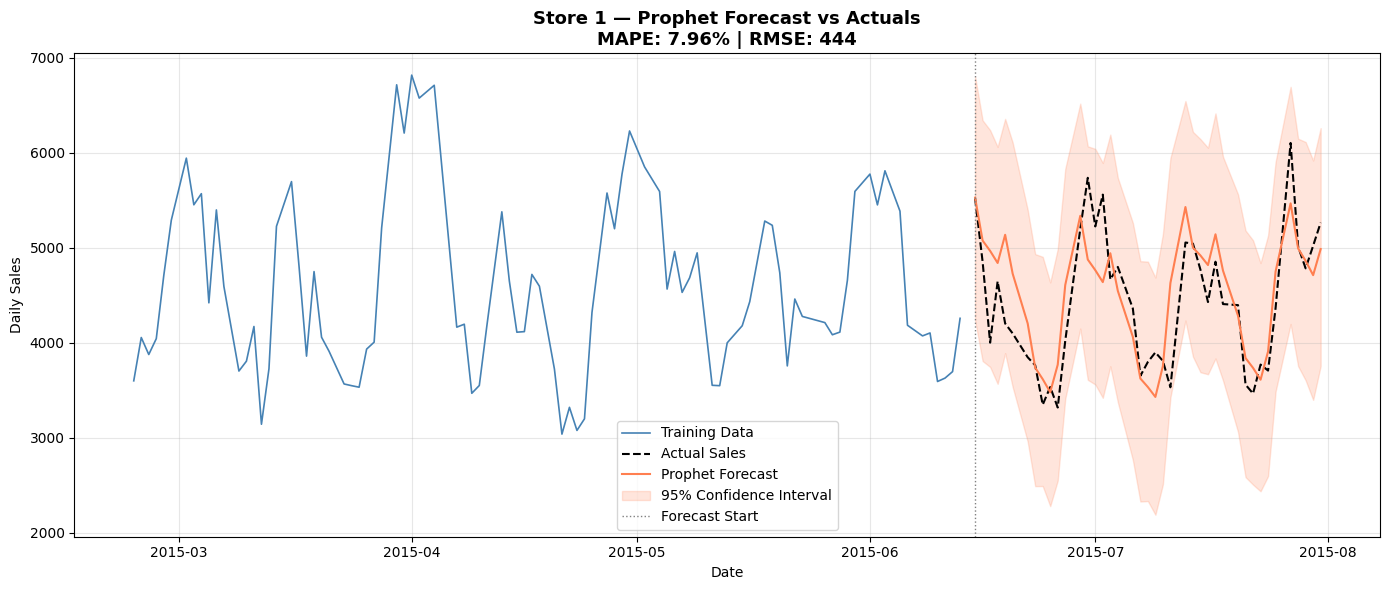

In [ ]:
fig, ax = plt.subplots(figsize=(14, 6))


train_tail = train_prophet.tail(90)
ax.plot(train_tail['ds'], train_tail['y'],
        color='steelblue', linewidth=1.2, label='Training Data')

ax.plot(test_prophet['ds'], test_prophet['y'],
        color='black', linewidth=1.5, linestyle='--', label='Actual Sales')


ax.plot(forecast['ds'], forecast['yhat'],
        color='coral', linewidth=1.5, label='Prophet Forecast')

ax.fill_between(forecast['ds'],
                forecast['yhat_lower'],
                forecast['yhat_upper'],
                color='coral', alpha=0.2, label='95% Confidence Interval')

ax.axvline(pd.Timestamp(split_date), color='gray',
           linestyle=':', linewidth=1, label='Forecast Start')
ax.set_title(f'Store 1 — Prophet Forecast vs Actuals\nMAPE: {mape_val:.2f}% | RMSE: {rmse:,.0f}',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Daily Sales')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('01_prophet_forecast.png', dpi=150, bbox_inches='tight')
plt.show()

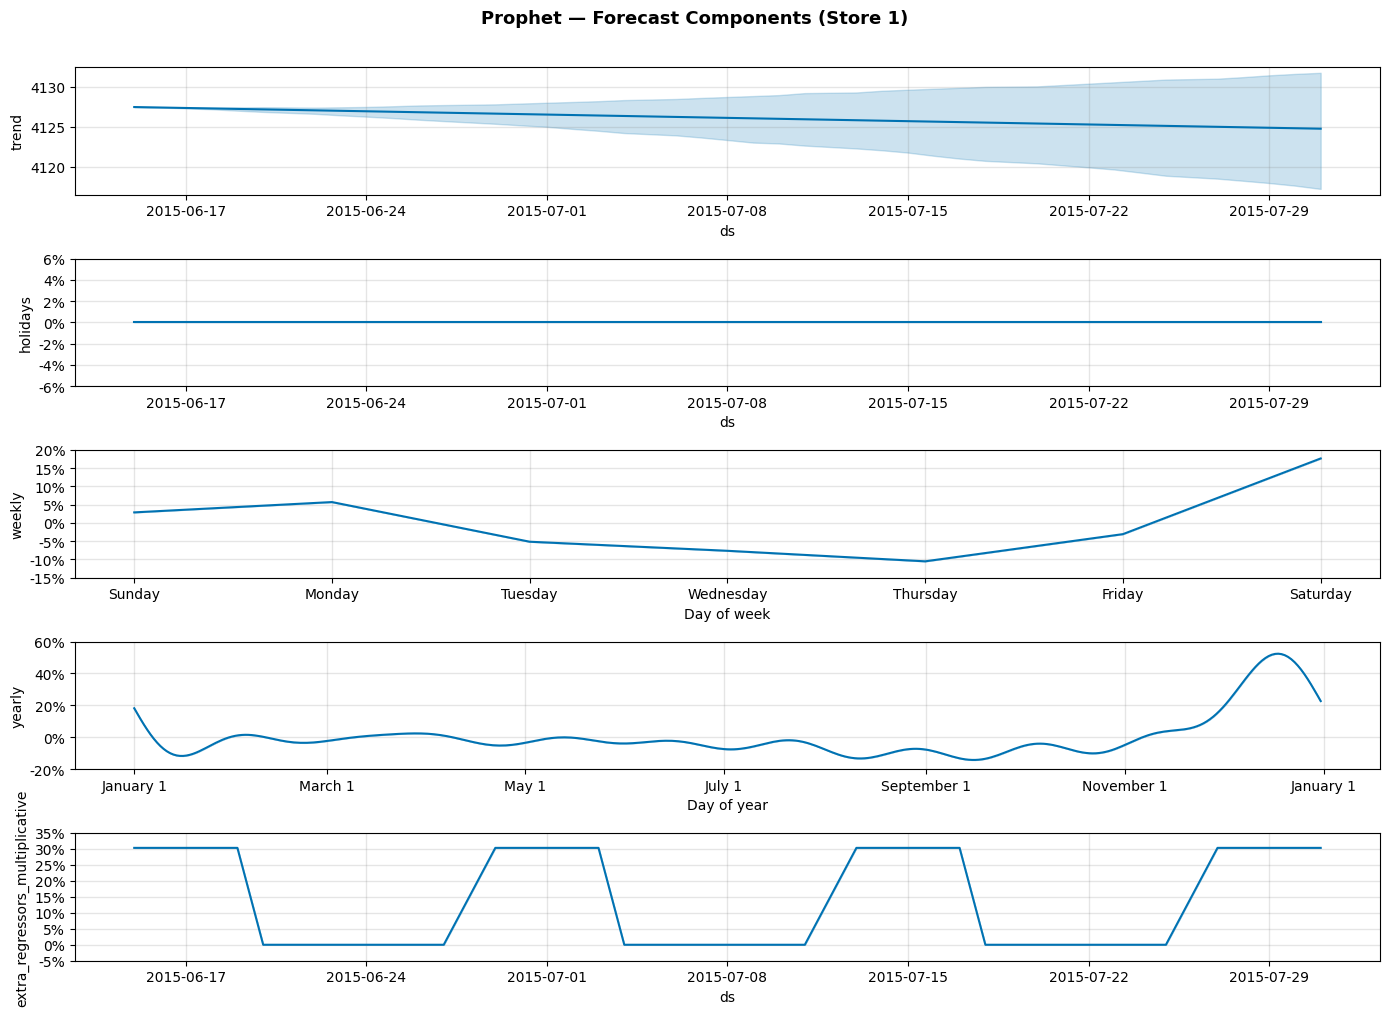

In [ ]:
fig = model.plot_components(forecast)
fig.set_size_inches(14, 10)
plt.suptitle('Prophet — Forecast Components (Store 1)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('02_prophet_components.png', dpi=150, bbox_inches='tight')
plt.show()

INFO:prophet:Making 4 forecasts with cutoffs between 2014-08-02 00:00:00 and 2015-04-29 00:00:00


Running cross validation — takes a few minutes...


  0%|          | 0/4 [00:00<?, ?it/s]


Cross Validation Performance:
   horizon         mae        rmse      mape
31 36 days  587.004929  688.942352  0.106592
32 37 days  573.989297  670.269559  0.108696
33 38 days  515.633503  593.727705  0.104452
34 39 days  494.574530  549.909854  0.111716
35 40 days  366.826022  435.053917  0.088234
36 41 days  307.209672  386.497923  0.076897
37 42 days  266.701917  370.692958  0.070357
38 43 days  291.501837  416.977758  0.068047
39 44 days  330.175727  452.269953  0.075967
40 45 days  416.916466  529.210555  0.088847


/usr/local/lib/python3.12/dist-packages/prophet/plot.py:547: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  x_plt = df_none['horizon'].astype('timedelta64[ns]').view(np.int64) / float(dt_conversions[i])
/usr/local/lib/python3.12/dist-packages/prophet/plot.py:548: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  x_plt_h = df_h['horizon'].astype('timedelta64[ns]').view(np.int64) / float(dt_conversions[i])


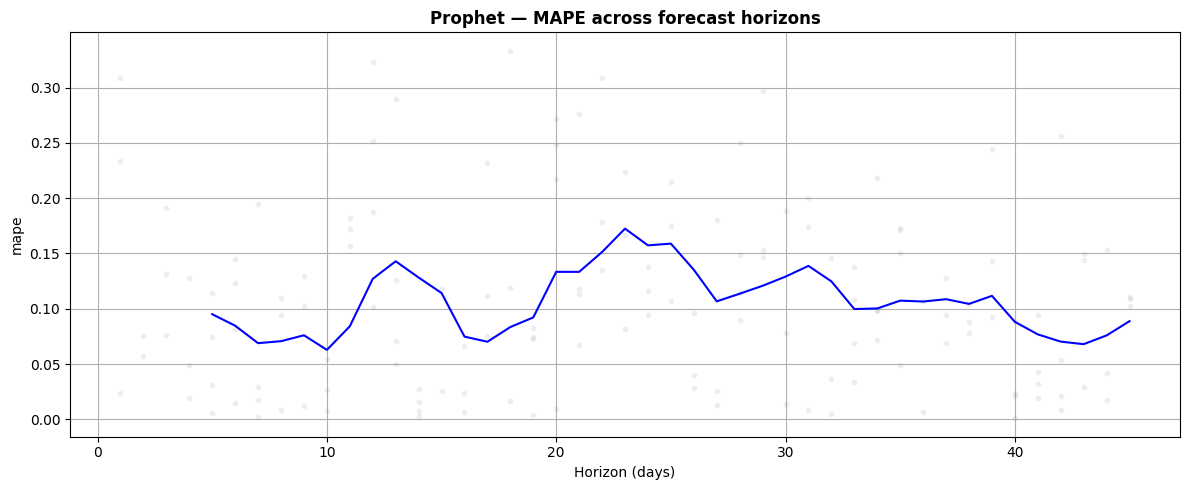

In [ ]:
print("Running cross validation — takes a few minutes...")

df_cv = cross_validation(
    model,
    initial='500 days',
    period='90 days',
    horizon='45 days',
    parallel=None
)

df_perf = performance_metrics(df_cv)

print("\nCross Validation Performance:")
print(df_perf[['horizon', 'mae', 'rmse', 'mape']].tail(10))

from prophet.plot import plot_cross_validation_metric

fig = plot_cross_validation_metric(df_cv, metric='mape')
fig.set_size_inches(12, 5)
plt.title('Prophet — MAPE across forecast horizons', fontweight='bold')
plt.tight_layout()
plt.savefig('03_cv_mape.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
with open('prophet_metrics.json', 'w') as f:
    json.dump(prophet_metrics, f)

print("=" * 45)
print("Prophet — Store 1 Results")
print("=" * 45)
print(f"{'Model':<12} {'MAE':>10} {'RMSE':>10} {'MAPE':>10}")
print("-" * 45)
print(f"{prophet_metrics['Model']:<12} {prophet_metrics['MAE']:>10,.2f} {prophet_metrics['RMSE']:>10,.2f} {prophet_metrics['MAPE']:>10.2f}%")
print("=" * 45)

Prophet — Store 1 Results
Model               MAE       RMSE       MAPE
---------------------------------------------
Prophet          344.91     443.65       7.96%
